## Setup

In [1]:
import random
import networkx as nx
import torch
import torch.nn as nn

from deep_ebm.utils_ebm import show_graph, evaluate_model
from deep_ebm.utils_ebm import save_graph, compare_graphs, show_graph_grid, compare_statistics
from deep_ebm.gnn_ebm import GraphDataset, GNN_EBM, train_one_epoch_pcd, gibbs_ministeps, evaluate_mmd_generated

from src.torch_erg import load_pglib_opf as lp
from src.torch_erg.samplers import GWGSampler, MHSampler, GWG_Hybrid_Sampler, MH_Hybrid_Sampler
from src.torch_erg.utils import laplacian_matrix,  unif_move, index_ravel_sampler
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle as pkl
from scipy.sparse.csgraph import connected_components
from scipy.sparse import csr_matrix

from Plots_and_utils.plots import *
from Plots_and_utils.other_g_stats import *

from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
with open("Saved_models/2community_GNN_EBM_50e_2000GS.pkl", "rb") as f:
    model_deep= pkl.load(f)

In [3]:
with open("data/TOY2community_dataset/TOY2comms_GraphDataset.pkl", "rb") as f:
    dataset_2community = pkl.load(f)

In [4]:
reference = dataset_2community[0][0]
ref_feats = dataset_2community[0][1]

In [5]:
model_deep(ref_feats, reference)

tensor(188.6816, grad_fn=<SqueezeBackward0>)

---

In [ ]:
class HybridSampler(GWG_Hybrid_Sampler):
    def __init__(self, backend: str, model: nn.Module):
        super().__init__(backend, model)
        self.model = model

    def observables(self, mtx):
        edges = torch.sum(mtx)/2
        triangles = torch.trace(torch.matmul(torch.matmul(mtx,mtx),mtx))/6
        return(torch.stack([edges, triangles]))

#we freeze the node features as we do not need them, so that we can evaluate the model only on the adj matrix
class NoFeatModel(nn.Module):
    def __init__(self, model, feats):
        super().__init__()
        self.model = model
        self.feats = feats.to(device)

    def forward(self,adj):
        return(self.model(self.feats, adj))

In [42]:
# Initial parameters
betas = torch.tensor([0., 0.])
weight_deep = 1
weight_erg = 1
niter_params = 500000
niter_sampling = 100000
params_update_every = 3
alpha = 0.001
min_change = 0.001

In [ ]:
adj_model = NoFeatModel(model_deep, ref_feats)

sampler = HybridSampler(backend="cuda",model = adj_model)
obs = sampler.observables(reference)
print("observed observables: ", obs)
reference = reference.to(device)

CUDA backend not available falling back to cpu
observed observables:  tensor([109., 127.])


In [90]:
params_only_deep = torch.tensor([0., 0.])

observables_deep, graphs_deep = sampler.sample_run(graph=reference,
                      observables=obs,
                      params=params_only_deep,
                      niter=niter_sampling,
                      save_every=50,
                      burn_in=0.2)

  0%|          | 4/100000 [00:00<44:27, 37.49it/s]

100%|██████████| 100000/100000 [11:34<00:00, 143.96it/s]

number of accepted steps is:  47782
number of rejected samples:  52218
Mean obs:  tensor([113.3154, 129.5975])


In [2]:
len(graphs_deep)

NameError: name 'graphs_deep' is not defined

In [ ]:
params, _ = sampler.param_run(graph=reference,
                      observables=obs,
                      params=betas,
                      niter=niter_params,
                      params_update_every=params_update_every,
                      save_every=50,
                      save_params=True,
                      alpha=alpha,
                      min_change=min_change)

100%|██████████| 500000/500000 [59:39<00:00, 139.68it/s]  

number of accepted steps is:  246992
number of rejected samples:  253008
number of effective updates is:  82330


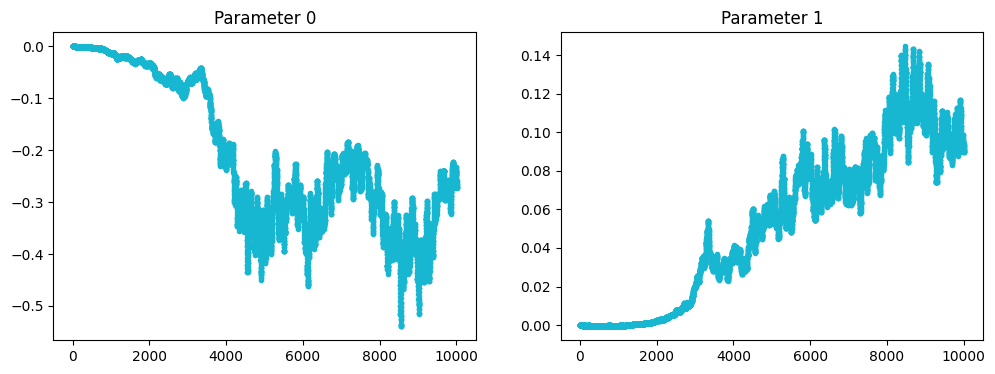

In [46]:
plot_params_iterations(params)

In [49]:
params_for_estimates = torch.stack(params[-1000:]).mean(axis = 0)
params_for_estimates

tensor([-0.3224,  0.0995])

In [59]:
observables_sampled, graphs_sampled = sampler.sample_run(graph=reference,
                      observables=obs,
                      params=params_for_estimates,
                      niter=100000,
                      save_every=50,
                      burn_in=0.2)

100%|██████████| 100000/100000 [11:36<00:00, 143.50it/s]

number of accepted steps is:  50109
number of rejected samples:  49891
Mean obs:  tensor([111.5153, 134.1662])


In [60]:
len(graphs_sampled)

1570

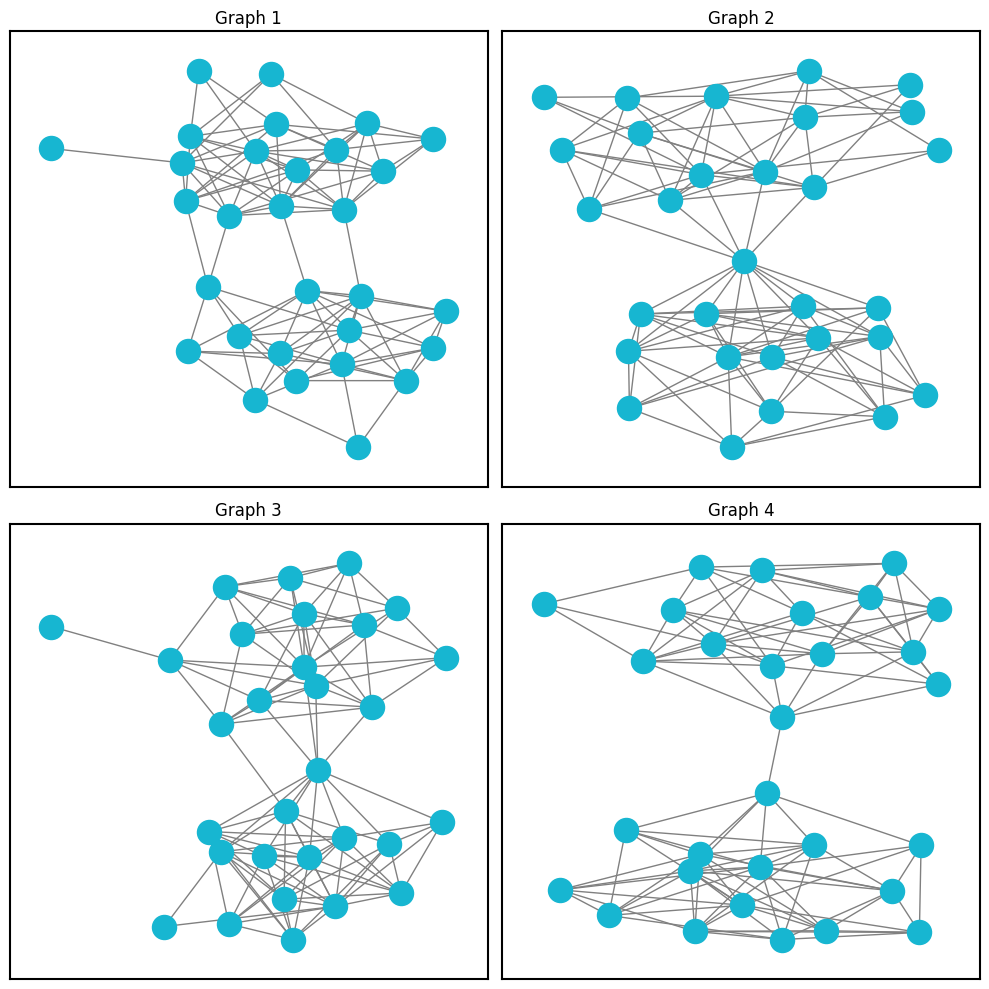

In [91]:
plot_random_graphs(graphs_sampled)

In [ ]:
def hist_obs_samples(observables_samples: list[torch.Tensor], observable_data: list[torch.Tensor], w = 10, h = 8, scale = 0.6, color = "#11a39c", bins = 30, obs_labels = None):
    num_obs = observables_samples[0].shape[0]
    figsize = (num_obs * w * scale, h * scale)
    
    gen_obs= torch.stack(observables_samples).cpu().numpy()
    data_obs = torch.stack(observable_data).cpu().numpy()

    fig, axes = plt.subplots(1, num_obs, figsize=figsize, squeeze=False)
    
    for p in range(num_obs):
        ax = axes[0, p]

        obs_samples = gen_obs[:, p]
        obs_data    = data_obs[:, p]

        # dataset
        ax.hist(
            obs_data, bins=bins, alpha=0.5, 
            label="Dataset", density=True
        )
        # generati
        ax.hist(
            obs_samples, bins=bins, alpha=0.5, 
            label="Generated", density=True
        )

        if obs_labels is not None:
            ax.set_title(f'{obs_labels[p]}')
        else:
            ax.set_title(f'Observable {p}')
        ax.legend()
    
    plt.tight_layout()
    plt.show()

In [ ]:
from src.torch_erg.utils import laplacian_matrix
from src.torch_erg.samplers import MHSampler_Hard

class Measurer(MHSampler_Hard):
    def __init__(self, backend: str):
        super().__init__(backend)

    def observables(self,mtx):
        L = laplacian_matrix(mtx)
        a3 = torch.matmul(torch.matmul(mtx,mtx),mtx)

        edges = torch.sum(mtx)/2
        triangles = torch.trace(a3)/6
        ac = torch.linalg.eigvalsh(L)[1]
        deg = torch.diagonal(L)
        tri_diag = torch.diagonal(a3) / 2

        valid = deg > 1
        local_clust = torch.zeros_like(deg)
        local_clust[valid] = tri_diag[valid] / (deg[valid] * (deg[valid] - 1))
        avg_clustering = torch.mean(local_clust[valid])

        avg_degree = torch.sum(mtx, dim=1).mean()

        return(torch.stack([edges, triangles, ac, avg_degree, avg_clustering]))

measurer = Measurer(backend='cpu')

In [ ]:
dataset_obs = [measurer.observables(g[0]) for g in dataset_2community]
only_deep_obs = [measurer.observables(g) for g in graphs_deep]
generated_obs = [measurer.observables(g) for g in graphs_sampled]

In [101]:
torch.stack(dataset_obs).mean(dim = 0), torch.stack(dataset_obs).std(dim=0)

(tensor([1.0603e+02, 1.1354e+02, 1.0209e-01, 7.0687e+00, 2.4433e-01]),
 tensor([7.4799e+00, 2.5325e+01, 6.4490e-03, 4.9866e-01, 2.4399e-02]))

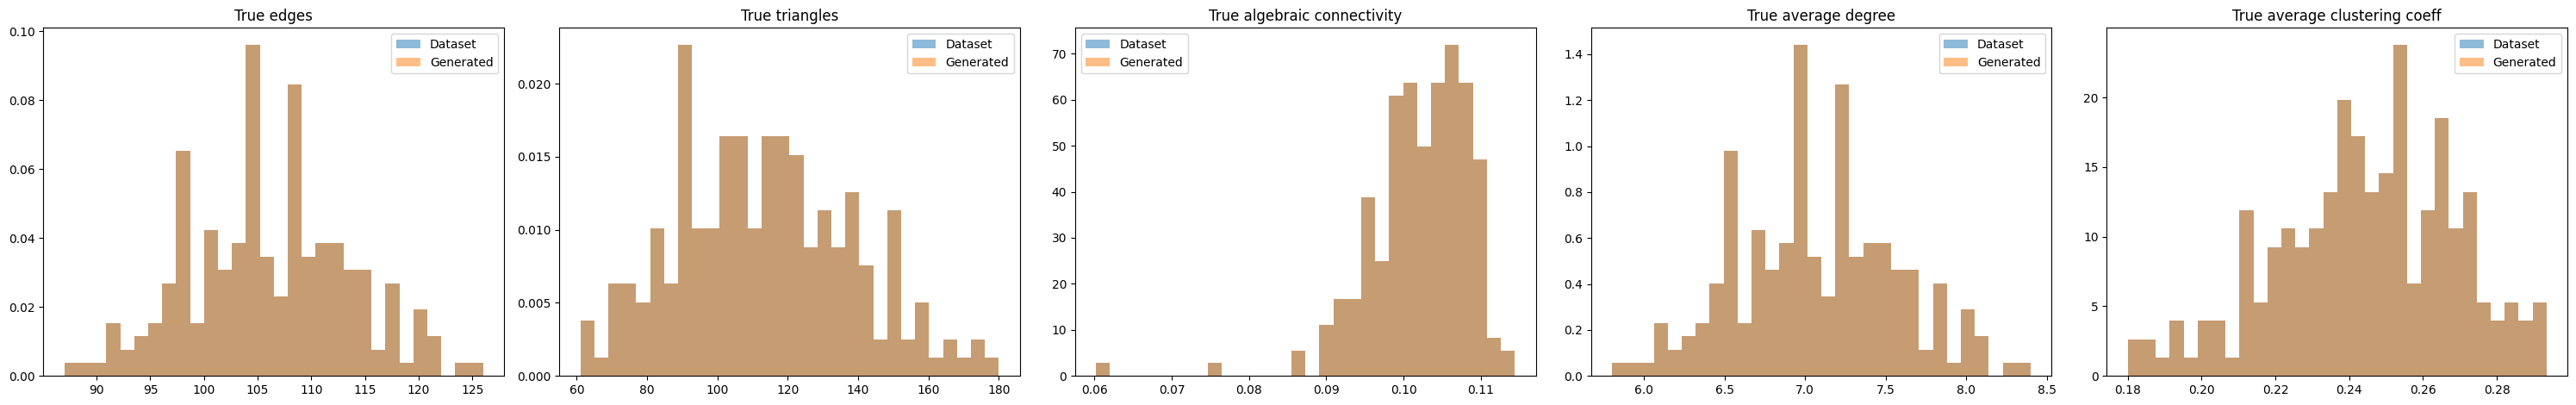

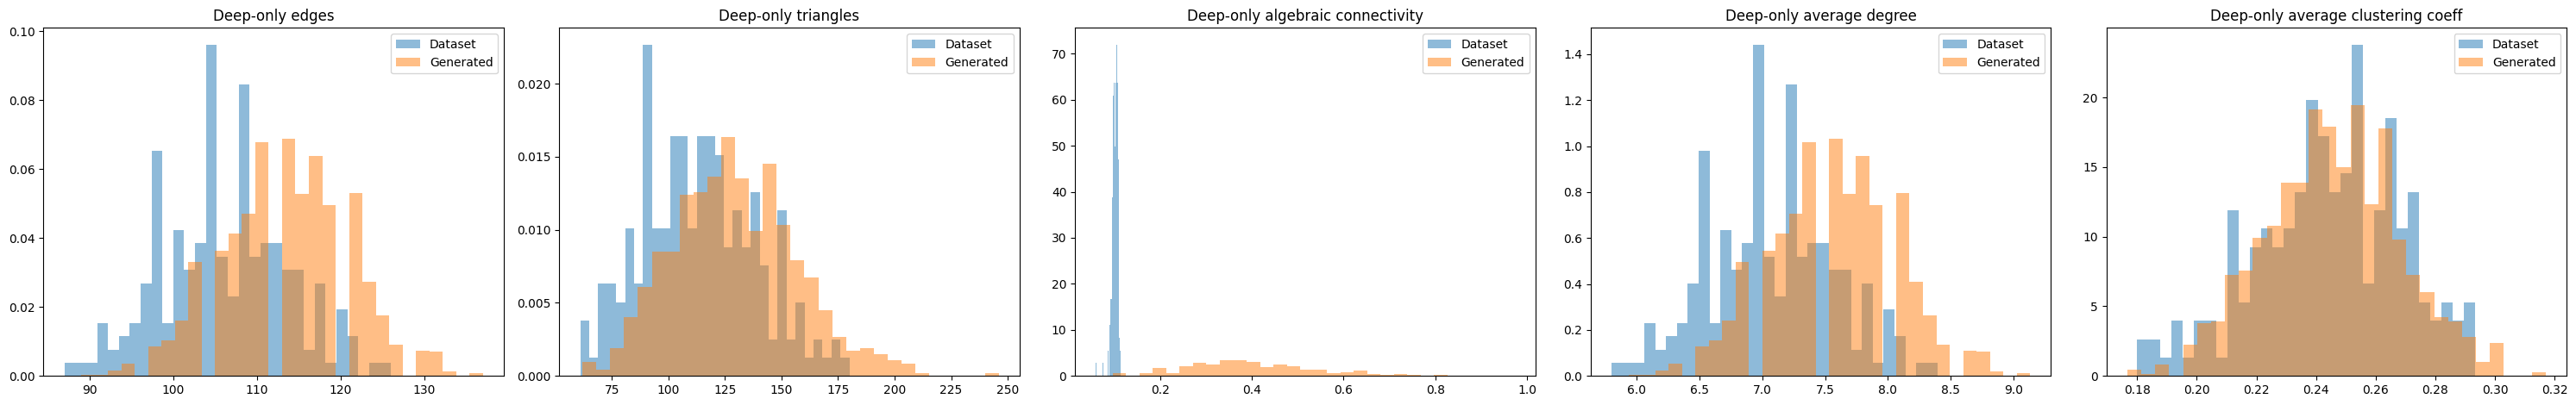

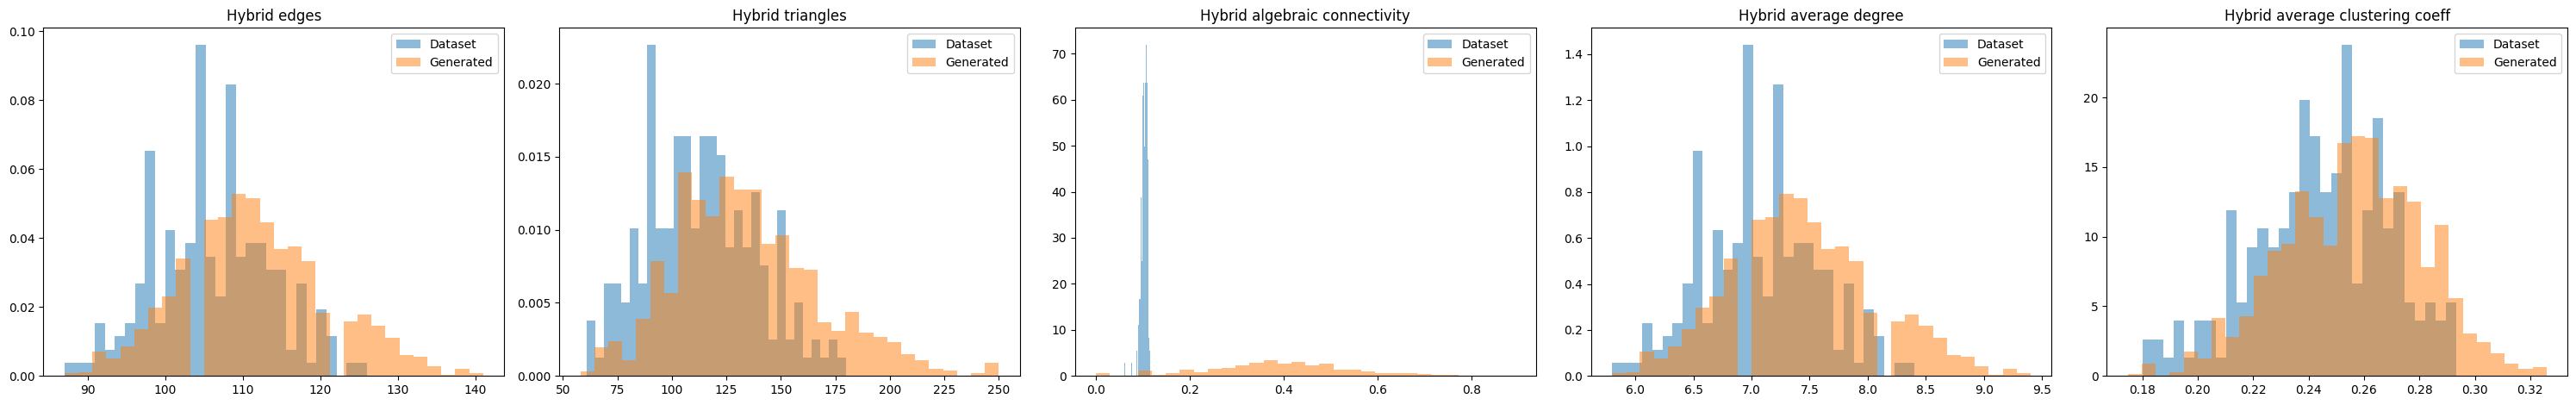

In [ ]:
hist_obs_samples(dataset_obs,dataset_obs, obs_labels=['True edges', 'True triangles', 'True algebraic connectivity', 'True average degree', 'True average clustering coeff'])
hist_obs_samples(only_deep_obs, dataset_obs, obs_labels=['Deep-only edges', 'Deep-only triangles', 'Deep-only algebraic connectivity', 'Deep-only average degree', 'Deep-only average clustering coeff'])
hist_obs_samples(generated_obs, dataset_obs, obs_labels=['Hybrid edges (no conditioning)', 'Hybrid triangles (no conditioning)', 'Hybrid algebraic connectivity (no conditioning)', 'Hybrid average degree (no conditioning)', 'Hybrid average clustering coeff (no conditioning)'])


---

## Energy landscape

In [ ]:
with open("data/30IEEE_synth_dataset/reduced_30IEEE_synth_list_netX.pkl", "rb") as f:
    netX_30IEEE = pkl.load(f)

with open("data/2community_dataset/2comms_list_netX.pkl", "rb") as f:
    netX_2community  = pkl.load(f)


data1 = GraphDataset(netX_30IEEE)
data2 = GraphDataset(netX_2community)
l1 = [nx.binomial_graph(30, 0.5) for _ in range(100)]
l2 = [nx.binomial_graph(30, 0.1) for _ in range(100)]
l3 = [nx.binomial_graph(30, 0.8) for _ in range(100)]
l4 = [nx.binomial_graph(30, 0.3) for _ in range(100)]
data3 = GraphDataset(l1 + l2 + l3 + l4)

fully_connected_graph = nx.complete_graph(30)

def get_embeddings_mixed(model, params, data1,data2,data3, w_e = 1, w_d = 1):
    complessive_energy = []

    for g in data1:
        adj = g[0]
        feats = g[1]
        energy = model(feats, adj).item()
        erg_energy = (params*sampler.observables(adj)).sum().item()
        energy = energy*w_d + erg_energy*w_e
        complessive_energy.append( (energy, 1) )
    for g in data2:
        adj = g[0]
        feats = g[1]
        energy = model(feats, adj).item()
        erg_energy = (params*sampler.observables(adj)).sum().item()
        energy = energy*w_d + erg_energy*w_e
        complessive_energy.append( (energy, 2) )
    for g in data3:
        adj = g[0]
        feats = g[1]
        energy = model(feats, adj).item()
        erg_energy = (params*sampler.observables(adj)).sum().item()
        energy = energy*w_d + erg_energy*w_e
        complessive_energy.append( (energy, 3) )
    
    return complessive_energy

In [ ]:
complessive_energy = get_embeddings_mixed(model_deep, params_for_estimates, data1, data2, data3, w_e=1, w_d=1)

In [ ]:
(params_for_estimates*sampler.observables(reference)).sum().item(), model_deep(ref_feats, reference)

(0.0, tensor(188.6816, grad_fn=<SqueezeBackward0>))

In [ ]:
def plot_embeddings_hist(complessive_energy, title, bins=30, xlim=None):
    labels_name = {1: "30IEEE", 2: "2community", 3: "Binomial graphs"}
    
    energies_by_label = {1: [], 2: [], 3: []}
    for e, l in complessive_energy:
        energies_by_label[l].append(e)

    colors = {1: "tab:blue", 2: "tab:orange", 3: "tab:green"}

    plt.figure(figsize=(8,5))

    for label in [1, 2, 3]:
        data = np.array(energies_by_label[label])
        # density=True → normalizza in modo che l'area sia 1 (per confrontare le forme)
        plt.hist(data, bins=bins, density=True, alpha=0.4, 
                 color=colors[label], label=labels_name[label])
    
    if xlim is not None:
        plt.xlim(xlim)
    plt.xlabel("Model prediction")
    plt.ylabel("Proportion (normalized histogram)")
    plt.title(title)
    plt.legend()
    plt.show()

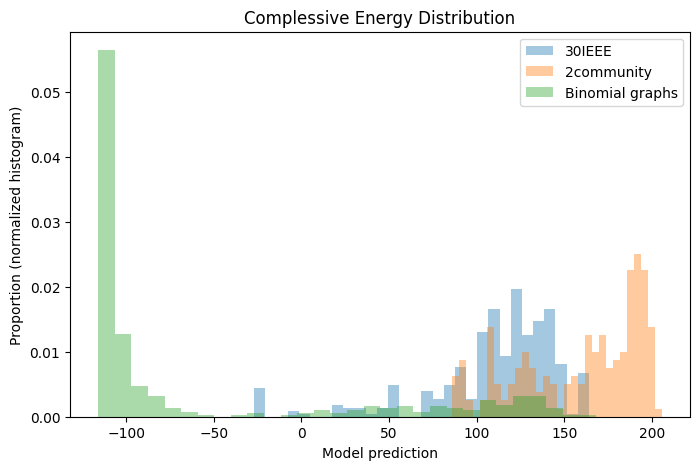

In [ ]:
plot_embeddings_hist(complessive_energy, "Complessive Energy Distribution")

---

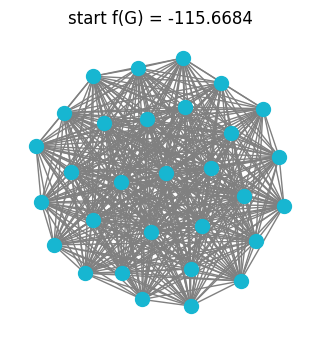

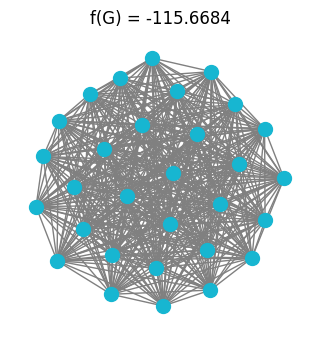

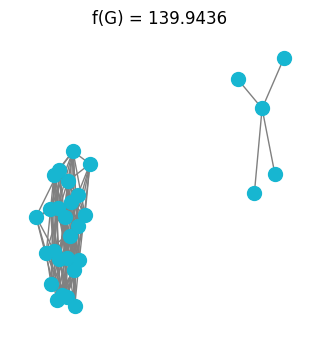

KeyboardInterrupt: 

In [ ]:
its = 100000
plot_every = 20000

energies_iterations = []

A, feats = dataset_2community[0]
A = torch.Tensor(nx.to_numpy_array(nx.binomial_graph(30, 1)))

energy = model_deep(feats, A)
plot_graph(A, w = 3, h = 3, node_size=100, title=f"start f(G) = {energy:.4f}")

for i in range(its):
    A = gibbs_ministeps(A, model_deep, feats.to(device), device, mini_steps=1)
    energy = model_deep(feats, A)
    if i % plot_every == 0 or i == its - 1:
        plot_graph(A, w = 3, h = 3, node_size=100, title=f"f(G) = {energy:.4f}")
    energies_iterations.append(energy.item())

In [ ]:
plt.plot(energies_iterations)
for i in range(its//plot_every):
    plt.axvline(i*plot_every, color='gray', linestyle='--', linewidth=0.5)

In [ ]:
generated = []
generated_tensors = []

with torch.no_grad():
    for i in range(20):
        A, feats = dataset_2community[i]
        A = torch.Tensor(nx.to_numpy_array(nx.binomial_graph(30, 0.5)))
        A_gen = gibbs_ministeps(A, model_deep, feats.to(device), device, mini_steps=1000)
        G_gen = nx.from_numpy_array(A_gen.cpu().numpy())
        generated.append(G_gen)
        generated_tensors.append(torch.tensor(A_gen.cpu().numpy()))

In [ ]:
plot_random_graphs(generated_tensors, 4)